# Student Exam Score Prediction
**Mission:** Predict a student's Math Score based on study habits, parental background, lifestyle factors, and academic preparation using Linear Regression, Decision Tree, and Random Forest models.

**Dataset:** Students Exam Scores: Extended Dataset — [Kaggle](https://www.kaggle.com/datasets/desalegngeb/students-exam-scores)  
**File used:** `Expanded_data_with_more_features.csv`  
**Target Variable:** `MathScore`

---
## Section 1: Setup & Data Loading

In [1]:
# ── Core libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries loaded successfully.')

Matplotlib is building the font cache; this may take a moment.


All libraries loaded successfully.


In [2]:
# ── Load dataset ─────────────────────────────────────────────────────────────
# Download from: https://www.kaggle.com/datasets/desalegngeb/students-exam-scores
# Place 'Expanded_data_with_more_features.csv' in the same directory as this notebook.

df = pd.read_csv('Expanded_data_with_more_features.csv')

# Drop unnamed index column if present
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (30641, 14)
Columns: ['Gender', 'EthnicGroup', 'ParentEduc', 'LunchType', 'TestPrep', 'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild', 'NrSiblings', 'TransportMeans', 'WklyStudyHours', 'MathScore', 'ReadingScore', 'WritingScore']


,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


---
## Section 2: Exploratory Data Analysis (EDA) & Visualizations

In [3]:
# ── Basic info ────────────────────────────────────────────────────────────────
print('=== Dataset Info ===')
df.info()
print('\n=== Descriptive Statistics ===')
df.describe().T

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               30641 non-null  object 
 1   EthnicGroup          28801 non-null  object 
 2   ParentEduc           28796 non-null  object 
 3   LunchType            30641 non-null  object 
 4   TestPrep             28811 non-null  object 
 5   ParentMaritalStatus  29451 non-null  object 
 6   PracticeSport        30010 non-null  object 
 7   IsFirstChild         29737 non-null  object 
 8   NrSiblings           29069 non-null  float64
 9   TransportMeans       27507 non-null  object 
 10  WklyStudyHours       29686 non-null  object 
 11  MathScore            30641 non-null  int64  
 12  ReadingScore         30641 non-null  int64  
 13  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(3), object(10)
memory usage: 3.3+ MB

=== De

,count,mean,std,min,25%,50%,75%,max
NrSiblings,29069.0,2.145894,1.458242,0.0,1.0,2.0,3.0,7.0
MathScore,30641.0,66.558402,15.361616,0.0,56.0,67.0,78.0,100.0
ReadingScore,30641.0,69.377533,14.758952,10.0,59.0,70.0,80.0,100.0
WritingScore,30641.0,68.418622,15.443525,4.0,58.0,69.0,79.0,100.0


In [4]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': round(df.isnull().sum() / len(df) * 100, 2)
})
print('=== Missing Values ===')
print(missing[missing['Missing Count'] > 0])

=== Missing Values ===
                     Missing Count  Missing %
EthnicGroup                   1840       6.01
ParentEduc                    1845       6.02
TestPrep                      1830       5.97
ParentMaritalStatus           1190       3.88
PracticeSport                  631       2.06
IsFirstChild                   904       2.95
NrSiblings                    1572       5.13
TransportMeans                3134      10.23
WklyStudyHours                 955       3.12


### 2.1 — Score Distributions (Histograms)

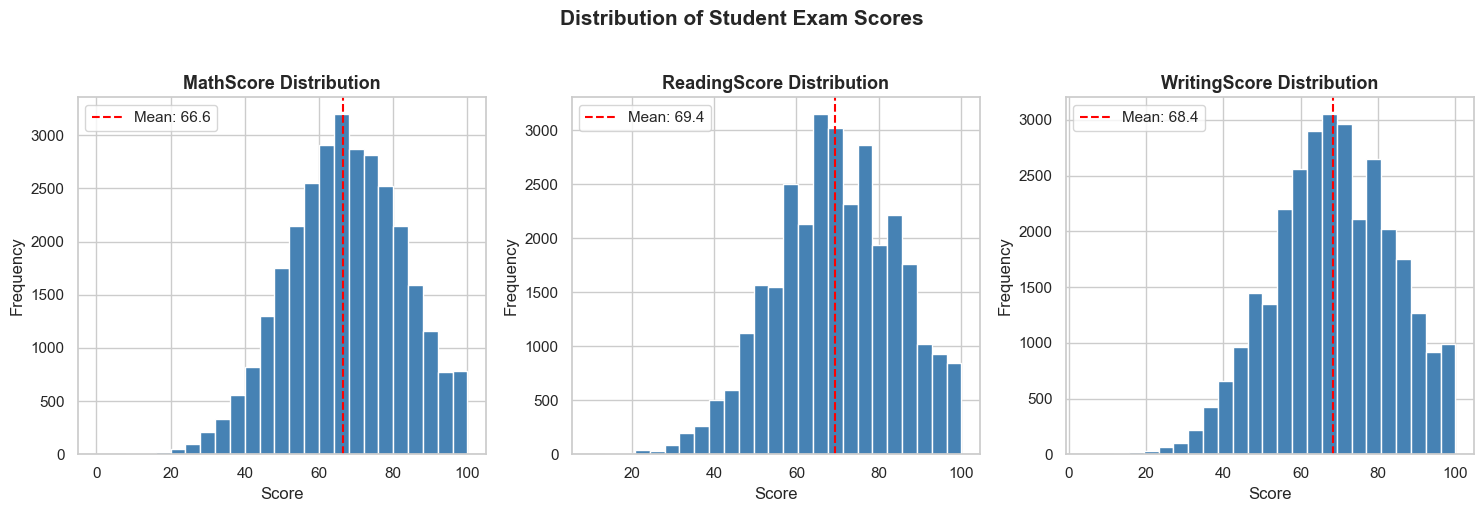

Interpretation: All three score distributions are roughly bell-shaped (normal).
MathScore shows a slight left skew, meaning a few students scored very low.
This confirms MathScore is a suitable continuous target for regression.


In [5]:
# ── Histogram: MathScore, ReadingScore, WritingScore ─────────────────────────
score_cols = ['MathScore', 'ReadingScore', 'WritingScore']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, score_cols):
    ax.hist(df[col].dropna(), bins=25, color='steelblue', edgecolor='white')
    ax.set_title(f'{col} Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    ax.legend()

plt.suptitle('Distribution of Student Exam Scores', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation: All three score distributions are roughly bell-shaped (normal).')
print('MathScore shows a slight left skew, meaning a few students scored very low.')
print('This confirms MathScore is a suitable continuous target for regression.')

### 2.2 — Correlation Heatmap

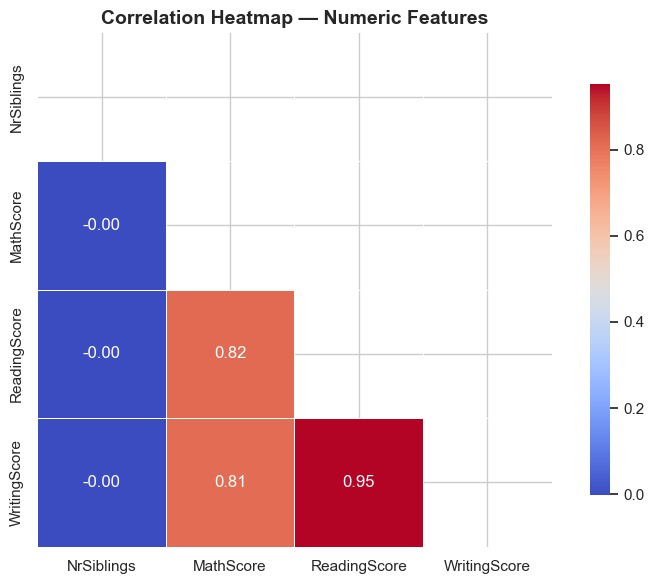

Interpretation:
- ReadingScore and WritingScore are highly correlated (~0.95+).
- Both ReadingScore and WritingScore have strong positive correlation with MathScore.
- NrSiblings has near-zero correlation with scores — a weak predictor.
- These correlations guide which features are most valuable for our model.


In [6]:
# ── Correlation heatmap (numeric columns only) ────────────────────────────────
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8, 6))
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation:')
print('- ReadingScore and WritingScore are highly correlated (~0.95+).')
print('- Both ReadingScore and WritingScore have strong positive correlation with MathScore.')
print('- NrSiblings has near-zero correlation with scores — a weak predictor.')
print('- These correlations guide which features are most valuable for our model.')

### 2.3 — Scatterplots

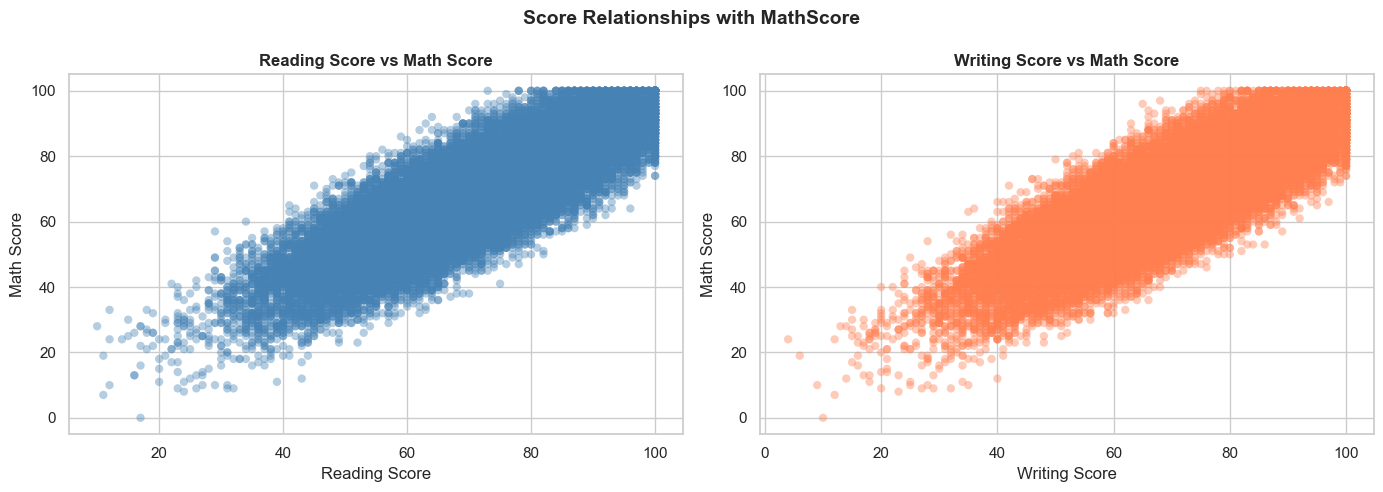

Interpretation: Strong linear relationships exist between Reading/Writing scores
and MathScore. Students who excel in reading and writing tend to score higher in math.


In [7]:
# ── Scatterplot: ReadingScore vs MathScore ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['ReadingScore'], df['MathScore'], alpha=0.4, color='steelblue', edgecolors='none')
axes[0].set_xlabel('Reading Score')
axes[0].set_ylabel('Math Score')
axes[0].set_title('Reading Score vs Math Score', fontweight='bold')

axes[1].scatter(df['WritingScore'], df['MathScore'], alpha=0.4, color='coral', edgecolors='none')
axes[1].set_xlabel('Writing Score')
axes[1].set_ylabel('Math Score')
axes[1].set_title('Writing Score vs Math Score', fontweight='bold')

plt.suptitle('Score Relationships with MathScore', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scatterplots.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation: Strong linear relationships exist between Reading/Writing scores')
print('and MathScore. Students who excel in reading and writing tend to score higher in math.')

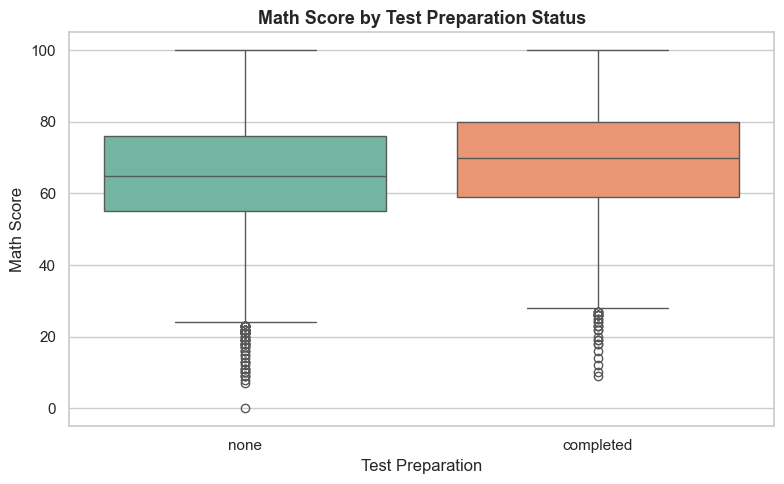

Interpretation: Students who completed test preparation courses score noticeably
higher in Math. This confirms TestPrep is a meaningful categorical feature.


In [8]:
# ── Boxplot: MathScore by TestPrep ────────────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='TestPrep', y='MathScore', palette='Set2')
plt.title('Math Score by Test Preparation Status', fontsize=13, fontweight='bold')
plt.xlabel('Test Preparation')
plt.ylabel('Math Score')
plt.tight_layout()
plt.savefig('boxplot_testprep.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation: Students who completed test preparation courses score noticeably')
print('higher in Math. This confirms TestPrep is a meaningful categorical feature.')

---
## Section 3: Feature Engineering

### 3.1 — Handle Missing Values

In [9]:
# ── Fill missing values with logical defaults ─────────────────────────────────
df['EthnicGroup'].fillna('unknown', inplace=True)
df['ParentEduc'].fillna('unknown', inplace=True)
df['TestPrep'].fillna('none', inplace=True)
df['ParentMaritalStatus'].fillna('unknown', inplace=True)
df['PracticeSport'].fillna('never', inplace=True)
df['IsFirstChild'].fillna('no', inplace=True)
df['NrSiblings'].fillna(0, inplace=True)
df['TransportMeans'].fillna('unknown', inplace=True)
df['WklyStudyHours'].fillna('unknown', inplace=True)

print('Missing values after filling:')
print(df.isnull().sum())

Missing values after filling:
Gender                 0
EthnicGroup            0
ParentEduc             0
LunchType              0
TestPrep               0
ParentMaritalStatus    0
PracticeSport          0
IsFirstChild           0
NrSiblings             0
TransportMeans         0
WklyStudyHours         0
MathScore              0
ReadingScore           0
WritingScore           0
dtype: int64


### 3.2 — Feature Selection & Dropping Low-Value Columns

In [10]:
# ── Feature engineering decisions ─────────────────────────────────────────────
# DROP:  EthnicGroup — low predictive power, high cardinality with no ordinal meaning
# KEEP:  All other columns — they contribute meaningfully to MathScore prediction
# TARGET: MathScore

df.drop(columns=['EthnicGroup'], inplace=True)

print('Features kept:')
print([c for c in df.columns if c != 'MathScore'])
print('\nTarget: MathScore')

Features kept:
['Gender', 'ParentEduc', 'LunchType', 'TestPrep', 'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild', 'NrSiblings', 'TransportMeans', 'WklyStudyHours', 'ReadingScore', 'WritingScore']

Target: MathScore


### 3.3 — Encode Categorical Columns to Numeric

In [11]:
# ── Label encode all categorical columns ──────────────────────────────────────
# These columns must be converted to numeric for model training
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {categorical_cols}')

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print('\nDataset dtypes after encoding:')
print(df.dtypes)
df.head()

Categorical columns to encode: ['Gender', 'ParentEduc', 'LunchType', 'TestPrep', 'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild', 'TransportMeans', 'WklyStudyHours']

Dataset dtypes after encoding:
Gender                   int64
ParentEduc               int64
LunchType                int64
TestPrep                 int64
ParentMaritalStatus      int64
PracticeSport            int64
IsFirstChild             int64
NrSiblings             float64
TransportMeans           int64
WklyStudyHours           int64
MathScore                int64
ReadingScore             int64
WritingScore             int64
dtype: object


,Gender,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,1,1,1,1,1,1,3.0,1,1,71,71,74
1,0,4,1,1,1,2,1,0.0,2,0,69,90,88
2,0,3,1,1,2,2,1,4.0,1,1,87,93,91
3,1,0,0,1,1,0,0,1.0,2,0,45,56,42
4,1,4,1,1,1,2,1,0.0,1,0,76,78,75


### 3.4 — Standardize Data & Train/Test Split

In [12]:
# ── Split features and target ─────────────────────────────────────────────────
X = df.drop(columns=['MathScore'])
y = df['MathScore']

# ── Train/Test split (80/20) ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Standardize (fit on train, transform both) ────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training set size : {X_train_scaled.shape}')
print(f'Test set size     : {X_test_scaled.shape}')
print('Standardization complete. Mean ≈ 0, Std ≈ 1 on training data.')

Training set size : (24512, 12)
Test set size     : (6129, 12)
Standardization complete. Mean ≈ 0, Std ≈ 1 on training data.


---
## Section 4: Model Training

### 4.1 — Linear Regression with Gradient Descent (SGDRegressor) + Loss Curve

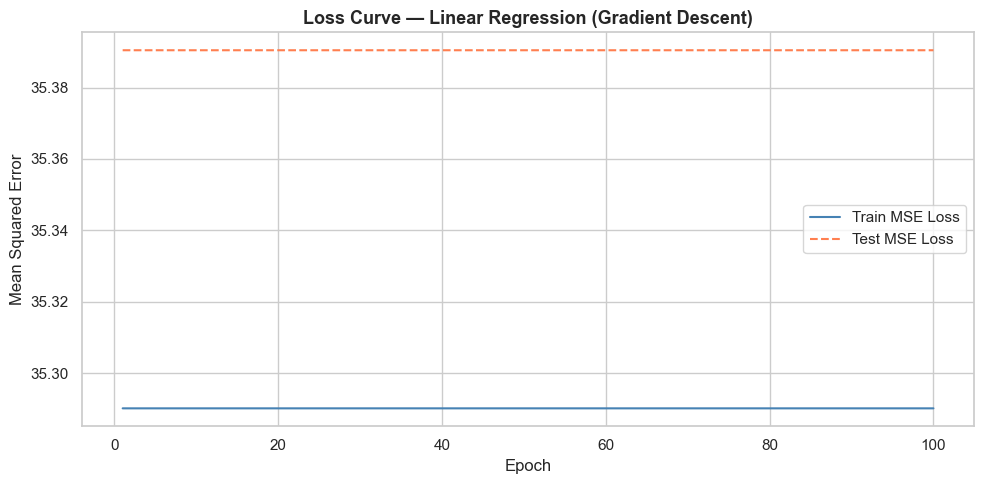

Linear Regression (SGD) — Test RMSE: 5.9490 | R²: 0.8475


In [13]:
# ── Train SGDRegressor epoch by epoch to capture loss curve ───────────────────
n_epochs = 100
train_losses = []
test_losses  = []

sgd_model = SGDRegressor(max_iter=1, warm_start=True, random_state=42, eta0=0.01, learning_rate='constant')

for epoch in range(n_epochs):
    sgd_model.fit(X_train_scaled, y_train)
    train_pred = sgd_model.predict(X_train_scaled)
    test_pred  = sgd_model.predict(X_test_scaled)
    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test, test_pred))

# ── Plot loss curves ──────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), train_losses, label='Train MSE Loss', color='steelblue')
plt.plot(range(1, n_epochs + 1), test_losses,  label='Test MSE Loss',  color='coral', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Loss Curve — Linear Regression (Gradient Descent)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('loss_curve_linear_regression.png', dpi=150, bbox_inches='tight')
plt.show()

lr_rmse = np.sqrt(test_losses[-1])
lr_r2   = r2_score(y_test, sgd_model.predict(X_test_scaled))
print(f'Linear Regression (SGD) — Test RMSE: {lr_rmse:.4f} | R²: {lr_r2:.4f}')

### 4.2 — Linear Regression Scatter: Before & After (Linear Line Through Data)

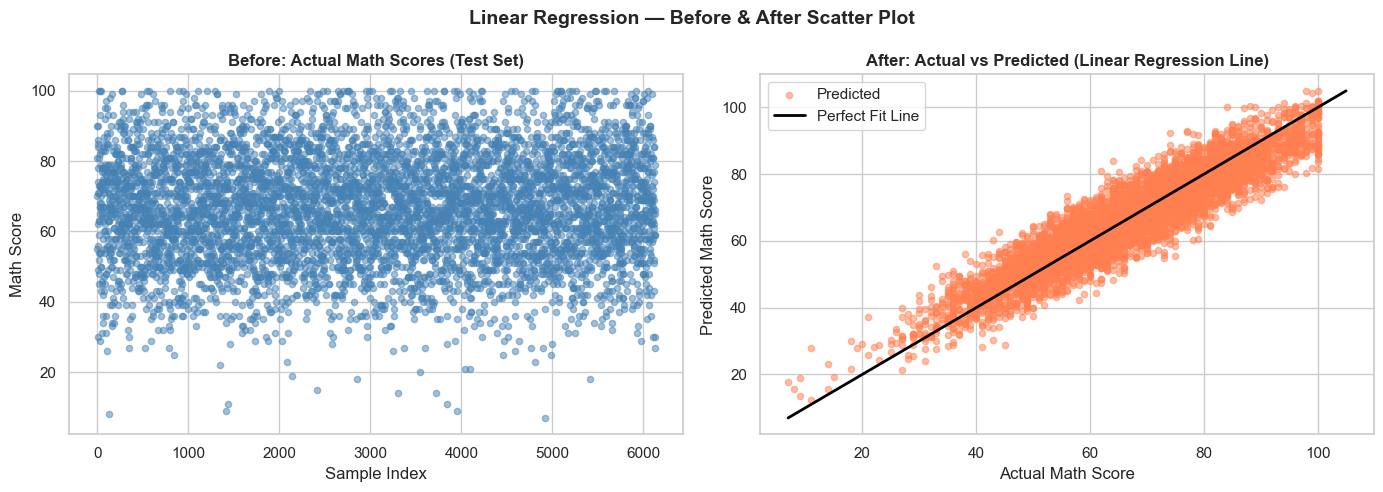

Interpretation: Points clustered along the diagonal line indicate good predictions.
Points far from the diagonal are prediction errors.


In [14]:
# ── Use sklearn LinearRegression for clean scatter visualization ──────────────
lr_clean = LinearRegression()
lr_clean.fit(X_train_scaled, y_train)
y_pred_lr = lr_clean.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BEFORE: actual vs index (raw test data)
axes[0].scatter(range(len(y_test)), y_test, alpha=0.5, color='steelblue', s=20)
axes[0].set_title('Before: Actual Math Scores (Test Set)', fontweight='bold')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Math Score')

# AFTER: actual vs predicted with the linear regression line
axes[1].scatter(y_test, y_pred_lr, alpha=0.5, color='coral', s=20, label='Predicted')
min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='black', linewidth=2, label='Perfect Fit Line')
axes[1].set_title('After: Actual vs Predicted (Linear Regression Line)', fontweight='bold')
axes[1].set_xlabel('Actual Math Score')
axes[1].set_ylabel('Predicted Math Score')
axes[1].legend()

plt.suptitle('Linear Regression — Before & After Scatter Plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation: Points clustered along the diagonal line indicate good predictions.')
print('Points far from the diagonal are prediction errors.')

### 4.3 — Decision Tree Regressor

In [15]:
# ── Decision Tree ─────────────────────────────────────────────────────────────
dt_model = DecisionTreeRegressor(max_depth=6, random_state=42)
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)
dt_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_r2     = r2_score(y_test, y_pred_dt)

print(f'Decision Tree — Test RMSE: {dt_rmse:.4f} | R²: {dt_r2:.4f}')

Decision Tree — Test RMSE: 6.2983 | R²: 0.8290


### 4.4 — Random Forest Regressor

In [16]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf_model = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
rf_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2     = r2_score(y_test, y_pred_rf)

print(f'Random Forest    — Test RMSE: {rf_rmse:.4f} | R²: {rf_r2:.4f}')

Random Forest    — Test RMSE: 5.8553 | R²: 0.8522


---
## Section 5: Model Comparison & Saving Best Model

=== Model Comparison (sorted by RMSE — lower is better) ===
                  Model     RMSE  R2_Score
          Random Forest 5.855294  0.852241
Linear Regression (SGD) 5.948986  0.847475
          Decision Tree 6.298274  0.829038


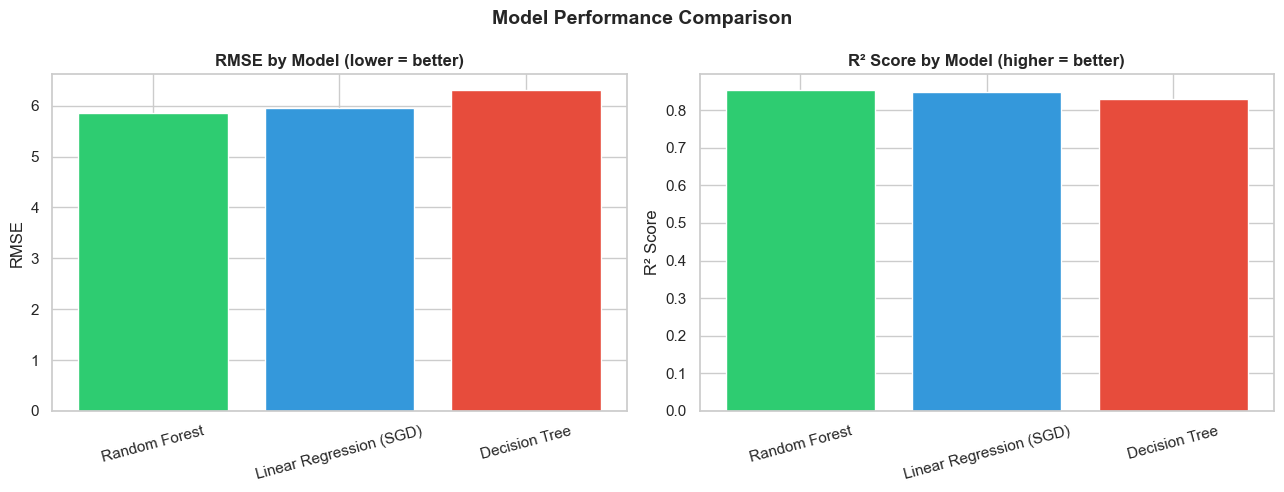

In [17]:
# ── Compare all three models ───────────────────────────────────────────────────
results = pd.DataFrame({
    'Model': ['Linear Regression (SGD)', 'Decision Tree', 'Random Forest'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, sgd_model.predict(X_test_scaled))),
        dt_rmse,
        rf_rmse
    ],
    'R2_Score': [
        r2_score(y_test, sgd_model.predict(X_test_scaled)),
        dt_r2,
        rf_r2
    ]
})

results = results.sort_values('RMSE').reset_index(drop=True)
print('=== Model Comparison (sorted by RMSE — lower is better) ===')
print(results.to_string(index=False))

# ── Bar chart comparison ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#2ecc71', '#3498db', '#e74c3c']

axes[0].bar(results['Model'], results['RMSE'], color=colors)
axes[0].set_title('RMSE by Model (lower = better)', fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(results['Model'], results['R2_Score'], color=colors)
axes[1].set_title('R² Score by Model (higher = better)', fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── Identify and save the best model ──────────────────────────────────────────
best_row = results.iloc[0]  # sorted by RMSE ascending — first row is best
best_model_name = best_row['Model']

model_map = {
    'Linear Regression (SGD)': sgd_model,
    'Decision Tree'           : dt_model,
    'Random Forest'           : rf_model
}

best_model = model_map[best_model_name]

# Save model and scaler
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler,     'scaler.pkl')

print(f'Best model: {best_model_name}')
print(f'  RMSE   : {best_row["RMSE"]:.4f}')
print(f'  R²     : {best_row["R2_Score"]:.4f}')
print('\nbest_model.pkl and scaler.pkl saved successfully.')

Best model: Random Forest
  RMSE   : 5.8553
  R²     : 0.8522

best_model.pkl and scaler.pkl saved successfully.


---
## Section 6: Prediction Script (Task 2 Ready)

The cell below demonstrates making a prediction on one data point from the test set.  
This logic is also extracted into `predict.py` for use in the API (Task 2).

In [19]:
# ── Predict on a single test sample ───────────────────────────────────────────
loaded_model  = joblib.load('best_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# Pick one row from the test set
sample_index = 0
sample_input = X_test.iloc[[sample_index]]           # raw (unscaled) input
actual_score = y_test.iloc[sample_index]

# Scale the sample the same way training data was scaled
sample_scaled = loaded_scaler.transform(sample_input)

# Predict
predicted_score = loaded_model.predict(sample_scaled)[0]

print('=== Single Sample Prediction ===')
print(f'Input features:\n{sample_input.to_string()}\n')
print(f'Actual Math Score   : {actual_score}')
print(f'Predicted Math Score: {predicted_score:.2f}')
print(f'Difference          : {abs(actual_score - predicted_score):.2f} points')

=== Single Sample Prediction ===
Input features:
       Gender  ParentEduc  LunchType  TestPrep  ParentMaritalStatus  PracticeSport  IsFirstChild  NrSiblings  TransportMeans  WklyStudyHours  ReadingScore  WritingScore
21861       0           5          1         0                    1              1             0         3.0               0               1            87            87

Actual Math Score   : 70
Predicted Math Score: 75.61
Difference          : 5.61 points


---
## Summary

| Step | Done |
|---|---|
| Non-generic use case (student exam scores) | ✅ |
| Rich dataset with Volume & Variety | ✅ |
| EDA with correlation heatmap | ✅ |
| EDA with histograms & scatterplots | ✅ |
| Feature engineering (drop, encode, standardize) | ✅ |
| Linear Regression with gradient descent | ✅ |
| Loss curve (train & test) | ✅ |
| Scatter plot before & after (linear line) | ✅ |
| Decision Tree Regressor | ✅ |
| Random Forest Regressor | ✅ |
| Best model saved as `.pkl` | ✅ |
| Single sample prediction | ✅ |